# Home Credit Default Risk — Model Card

## Executive Summary

This document summarizes the final credit risk model developed for the Home Credit Default Risk project. The model is intended to support loan approval decisions by estimating the probability that an applicant will have repayment difficulties.

The final approach uses a **Random Forest classifier** selected through **3-fold cross-validation** and then evaluated on Kaggle, where it achieved a **public leaderboard AUC of 0.71984**. Because the business problem is imbalanced and cost-sensitive, model selection emphasized **AUC** rather than accuracy alone.

For business use, a probability threshold must be chosen to convert predicted risk into an approve or deny recommendation. In this model card, that threshold is based on simple lending economics using public data. A conservative base case uses:
- a **24-month personal loan rate of 11.65%** from the Federal Reserve’s G.19 release
- an estimated **recovery rate of about 35%** based on LendingClub’s reported recoveries and charge-offs
- an implied **loss given default (LGD) of about 65%**

Using those assumptions, the model card recommends a **base-case denial threshold near 0.15** for predicted default probability. In plain terms, applicants with predicted default risk above about 15% would be flagged for denial or manual review under the base-case assumptions.

This recommendation should not be treated as production-ready policy by itself. It is a student project model built from Kaggle data, and the expected business value depends heavily on underwriting rules, pricing, acquisition cost, funding cost, servicing cost, and legal review. The fairness and adverse-action sections below highlight where extra governance would be required before deployment.


## Model Details

### Model Type
- **Final model:** Random Forest classifier
- **Selection method:** best-performing candidate from the modeling notebook based on **cross-validation performance**
- **Primary selection metric:** AUC
- **External benchmark:** Kaggle public leaderboard score

### Version
- **Project stage:** model card documentation for the Home Credit Default Risk portfolio project
- **Notebook artifact:** `model_card_notebook.ipynb`

### Training Data Summary
The model is trained on the Home Credit Default Risk training data and uses the cleaned, feature-engineered outputs prepared during the data preparation phase. The feature set includes:
- application-level borrower information
- aggregated applicant-level features from `bureau.csv`
- aggregated applicant-level features from `previous_application.csv`
- aggregated applicant-level features from `installments_payments.csv`
- optional supplementary engineered features from other related tables when available

### Key Hyperparameters
The final model notebook selected a tuned Random Forest model using randomized search on a subsample with 3-fold cross-validation. When you run the notebook, the section below captures the fitted parameter choices from the modeling workflow.


In [1]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, precision_score, recall_score
import matplotlib.pyplot as plt
!pip install shap

import shap


In [2]:

DATA_DIR = Path("/content")

# Update these paths if your prepared files use different names
train_path = DATA_DIR / 'application_train.csv'
test_path = DATA_DIR / 'application_test.csv'

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

ID_COL = "SK_ID_CURR"
TARGET_COL = "TARGET"

X = train_df.drop(columns=[TARGET_COL], errors="ignore")
y = train_df[TARGET_COL].copy()

if ID_COL in X.columns:
    X = X.drop(columns=[ID_COL])

# keep demographic fields for fairness later if they are present
fairness_cols = [c for c in ["CODE_GENDER", "NAME_EDUCATION_TYPE"] if c in train_df.columns]


In [3]:

def split_columns(df):
    numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
    categorical_cols = df.select_dtypes(exclude=["number"]).columns.tolist()
    return numeric_cols, categorical_cols

def build_preprocessor(X):
    numeric_cols, categorical_cols = split_columns(X)

    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_cols),
            ("cat", categorical_transformer, categorical_cols)
        ],
        remainder="drop"
    )
    return preprocessor


In [4]:

# Replace these with your exact tuned values if you want them hard-coded from the modeling notebook
final_model_params = {
    "n_estimators": 200,
    "max_depth": None,
    "min_samples_split": 20,
    "min_samples_leaf": 10,
    "max_features": "sqrt",
    "random_state": 42,
    "n_jobs": -1
}

preprocessor = build_preprocessor(X)

final_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(**final_model_params))
])

pd.DataFrame([final_model_params])


,n_estimators,max_depth,min_samples_split,min_samples_leaf,max_features,random_state,n_jobs
0,200,None,20,10,sqrt,42,-1


## Intended Use

### Intended Users
This model is designed for a business audience evaluating consumer lending decisions, such as:
- credit risk managers
- underwriting analysts
- portfolio managers
- business stakeholders deciding whether a model is ready for deployment

### Intended Decision Support Use
The model is intended to estimate the **probability of default** or repayment difficulty and help support:
- approve / deny decisions
- prioritization for manual review
- threshold-based lending policies
- portfolio risk monitoring

### Out of Scope
This model is **not** designed for:
- fully autonomous lending decisions without human governance
- compliance decisions without legal review
- adverse-action notices without human-readable explanation mapping
- use outside the Home Credit/Kaggle data environment
- use as a fairness-certified production underwriting system

It should be treated as a portfolio-grade analytics project, not a production-ready bank model.


## Performance Metrics

This section reports:
- **Cross-validated AUC** from the modeling workflow
- **Kaggle public leaderboard AUC**
- **Precision and recall** at the chosen business threshold

The Kaggle public score already recorded for this project is:

- **Kaggle public leaderboard AUC = 0.71984**

The cells below compute a validation-set AUC, precision, and recall so the threshold analysis can be connected to real predictions from the model.


In [5]:

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

final_model.fit(X_train, y_train)
valid_pred = final_model.predict_proba(X_valid)[:, 1]

validation_auc = roc_auc_score(y_valid, valid_pred)
pd.DataFrame([{
    "validation_auc_holdout": validation_auc,
    "kaggle_public_auc": 0.71984
}])


,validation_auc_holdout,kaggle_public_auc
0,0.741822,0.71984


## Decision Threshold Analysis

A model score is not a business decision by itself. To use the model operationally, the lender needs a threshold that turns predicted default probability into an approve or deny recommendation.

### Business Assumptions Used
This notebook uses public, real-world reference points rather than made-up values:

1. **Typical consumer lending price / profit proxy**  
   The Federal Reserve’s G.19 release reports the **24-month personal loan rate at 11.65% in 2025 Q4**. This is used here as a simple proxy for the gain on a repaid loan.  
   Source: Federal Reserve G.19 consumer credit release.

2. **Typical recovery rate after default**  
   LendingClub reported **consumer recoveries of 16.62 million against consumer charge-offs of 47.886 million** for the quarter ended September 30, 2025. That implies a rough recovery ratio of about **34.7%**.  
   Source: LendingClub third-quarter 2025 results.

3. **Loss given default (LGD)**  
   Using that recovery proxy, the implied LGD is approximately **65.3%**.

### Base-Case Threshold Logic
If:
- gain from an approved loan that repays = **+11.65%**
- loss from an approved loan that defaults = **-65.3%**

then the expected value of approving a loan is positive when:

**(1 − p_default) × gain − p_default × loss > 0**

which simplifies to:

**p_default < gain / (gain + loss)**

Under the base case, that produces an approximate threshold near **0.15**.

This is intentionally conservative and simple. It is a decision-support threshold, not a final underwriting policy.


In [6]:

gain_repaid = 0.1165
recovery_rate = 16.620 / 47.886
lgd = 1 - recovery_rate
base_threshold = gain_repaid / (gain_repaid + lgd)

pd.DataFrame([{
    "gain_if_repaid_proxy": gain_repaid,
    "recovery_rate_proxy": recovery_rate,
    "loss_given_default_proxy": lgd,
    "recommended_base_threshold": base_threshold
}]).round(4)


,gain_if_repaid_proxy,recovery_rate_proxy,loss_given_default_proxy,recommended_base_threshold
0,0.1165,0.3471,0.6529,0.1514


In [7]:

chosen_threshold = float(base_threshold)

pred_label = (valid_pred >= chosen_threshold).astype(int)

precision = precision_score(y_valid, pred_label, zero_division=0)
recall = recall_score(y_valid, pred_label, zero_division=0)

pd.DataFrame([{
    "chosen_threshold": chosen_threshold,
    "precision_at_threshold": precision,
    "recall_at_threshold": recall
}]).round(4)


,chosen_threshold,precision_at_threshold,recall_at_threshold
0,0.1514,0.2574,0.3456


### Sensitivity Analysis

The exact best threshold depends on business assumptions. A more conservative lender may prefer a lower threshold, while a lender prioritizing growth may accept a higher threshold. The table and chart below show how approvals, expected value, precision, and recall change as the threshold changes.

The expected-value calculation below uses the same simplified assumptions:
- approve the loan when predicted default probability is below the threshold
- if the loan repays, gain = +11.65%
- if the loan defaults, loss = −65.3%


In [8]:

def threshold_metrics(y_true, pred_prob, threshold, gain, loss):
    approve = pred_prob < threshold
    approved_n = approve.sum()
    approval_rate = approve.mean()

    approved_defaults = y_true[approve].sum() if approved_n > 0 else 0
    approved_nondefaults = approved_n - approved_defaults

    expected_value = approved_nondefaults * gain - approved_defaults * loss

    pred_default = (pred_prob >= threshold).astype(int)
    precision = precision_score(y_true, pred_default, zero_division=0)
    recall = recall_score(y_true, pred_default, zero_division=0)

    return {
        "threshold": threshold,
        "approval_rate": approval_rate,
        "approved_loans": approved_n,
        "approved_defaults": int(approved_defaults),
        "approved_nondefaults": int(approved_nondefaults),
        "expected_value_proxy": expected_value,
        "precision_default_flag": precision,
        "recall_default_flag": recall
    }

threshold_grid = np.round(np.arange(0.05, 0.51, 0.05), 2)
threshold_table = pd.DataFrame([
    threshold_metrics(y_valid.values, valid_pred, t, gain_repaid, lgd)
    for t in threshold_grid
])

threshold_table.round(4)


,threshold,approval_rate,approved_loans,approved_defaults,approved_nondefaults,expected_value_proxy,precision_default_flag,recall_default_flag
0,0.05,0.3317,20403,529,19874,1969.9233,0.1079,0.8935
1,0.10,0.7254,44617,1993,42624,3664.4151,0.1760,0.5986
2,0.15,0.8887,54656,3221,51435,3889.1038,0.2547,0.3513
3,0.20,0.9565,58825,4076,54749,3716.9334,0.3320,0.1791
4,0.25,0.9840,60516,4570,55946,3533.8386,0.4002,0.0796
5,0.30,0.9946,61170,4805,56365,3429.2145,0.4805,0.0322
6,0.35,0.9987,61426,4921,56505,3369.7851,0.5714,0.0089
7,0.40,0.9998,61491,4956,56535,3350.4277,0.7500,0.0018
8,0.45,1.0000,61503,4965,56538,3344.9009,0.0000,0.0000
9,0.50,1.0000,61503,4965,56538,3344.9009,0.0000,0.0000


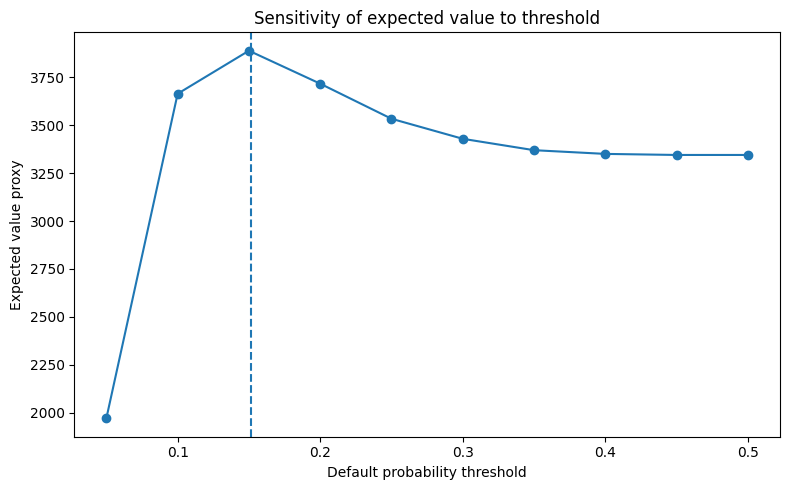

In [9]:

plt.figure(figsize=(8, 5))
plt.plot(threshold_table["threshold"], threshold_table["expected_value_proxy"], marker="o")
plt.axvline(chosen_threshold, linestyle="--")
plt.xlabel("Default probability threshold")
plt.ylabel("Expected value proxy")
plt.title("Sensitivity of expected value to threshold")
plt.tight_layout()
plt.show()


## Explainability

Most machine learning models produce a prediction without a direct reason. To support deployment, the model should also provide understandable explanations for why a borrower was considered lower or higher risk.

This notebook uses **SHAP** on a **1,000-row sample** for speed. The goal is to identify the features that most strongly influence model predictions overall.

If SHAP is not already installed in your environment, run:

```bash
pip install shap
```


In [11]:

# SHAP can be slow, so use a 1,000-row sample
sample_n = min(1000, len(X_valid))
X_shap_sample = X_valid.sample(sample_n, random_state=42)

# Fit the preprocessor separately so we can get transformed features
preprocessor_fitted = build_preprocessor(X_train)
X_train_trans = preprocessor_fitted.fit_transform(X_train)
X_shap_trans = preprocessor_fitted.transform(X_shap_sample)

rf_for_shap = RandomForestClassifier(**final_model_params)
rf_for_shap.fit(X_train_trans, y_train)

feature_names = preprocessor_fitted.get_feature_names_out()


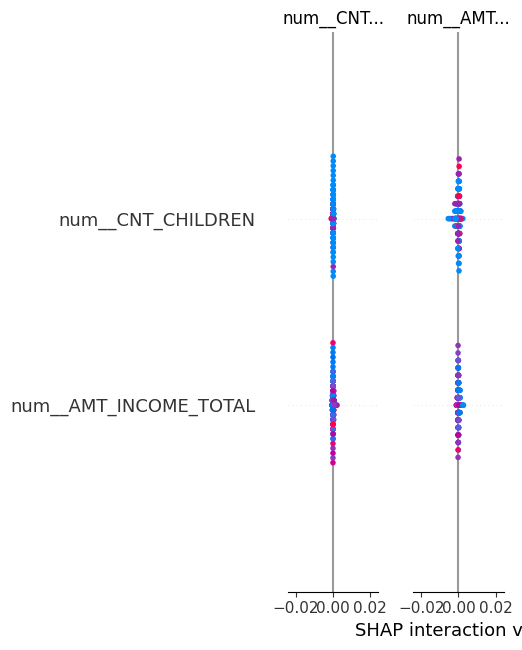

In [14]:
import shap
import numpy as np

# Convert to numpy array for SHAP
X_shap_np = np.asarray(X_shap_trans, dtype=np.float32)

# Sample rows for explanation (reduced for speed)
n_shap = min(200, X_shap_np.shape[0])
idx = np.random.choice(X_shap_np.shape[0], n_shap, replace=False)
X_shap_small = X_shap_np[idx]

explainer = shap.TreeExplainer(
    rf_for_shap,
    feature_perturbation="tree_path_dependent"
)

# Optionally limit trees for more speed
# Disable check_additivity to resolve ExplainerError
shap_values = explainer.shap_values(X_shap_small, tree_limit=50, check_additivity=False)

# For binary classification, use the positive class where needed
if isinstance(shap_values, list):
    shap_array = shap_values[1]
else:
    shap_array = shap_values

shap.summary_plot(shap_array, X_shap_small, feature_names=feature_names, show=False)
plt.tight_layout()
plt.show()

In [16]:

# Ensure shap_array is correctly extracting the positive class (index 1)
# from the 3D shap_values (samples, features, classes)
if shap_array.ndim == 3 and shap_array.shape[2] == 2:
    shap_array_positive_class = shap_array[:, :, 1]
elif shap_array.ndim == 2:
    # This case might happen if shap_values was already a list and shap_array = shap_values[1]
    shap_array_positive_class = shap_array
else:
    raise ValueError("Unexpected shape for shap_array. Expected 2D or 3D with 2 classes.")

mean_abs_shap = np.abs(shap_array_positive_class).mean(axis=0)
top_features = (
    pd.DataFrame({
        "feature": feature_names,
        "mean_abs_shap": mean_abs_shap
    })
    .sort_values("mean_abs_shap", ascending=False)
    .head(15)
)

top_features


,feature,mean_abs_shap
28,num__EXT_SOURCE_2,0.004134
29,num__EXT_SOURCE_3,0.003824
27,num__EXT_SOURCE_1,0.001362
7,num__DAYS_EMPLOYED,0.001222
77,num__DAYS_LAST_PHONE_CHANGE,0.001125
6,num__DAYS_BIRTH,0.001111
107,cat__CODE_GENDER_M,0.001067
4,num__AMT_GOODS_PRICE,0.000971
129,cat__NAME_EDUCATION_TYPE_Higher education,0.000846
106,cat__CODE_GENDER_F,0.000809


### Interpreting the SHAP Section

The SHAP summary identifies which features most strongly push predictions toward higher or lower default risk. In a business context, these are the features most likely to drive:
- risk ranking
- denial reasons
- manual review policies
- fairness concerns

Because the exact top features depend on your trained run, the table above should be treated as the source of truth for this project when you execute the notebook.


## Adverse Action Mapping

A score alone is not enough for a declined borrower. Denial reasons should be understandable to a human being. The table below maps common Home Credit features into plain-language explanations.

These mappings should be reviewed by a compliance or legal team before any real use, but they provide a practical starting point for explaining model decisions.


In [17]:

adverse_action_map = {
    "EXT_SOURCE_1": "Limited external credit history or weaker external credit signals",
    "EXT_SOURCE_2": "Limited external credit history or weaker external credit signals",
    "EXT_SOURCE_3": "Limited external credit history or weaker external credit signals",
    "AMT_CREDIT": "Requested loan amount is high relative to the applicant's financial profile",
    "AMT_ANNUITY": "Projected payment obligation is high relative to income",
    "AMT_INCOME_TOTAL": "Reported income may be insufficient for the requested loan size",
    "credit_to_income": "Debt request appears high relative to income",
    "annuity_to_income": "Monthly payment burden appears high relative to income",
    "bureau_debt_sum": "Existing debt obligations appear elevated",
    "bureau_overdue_sum": "Past-due credit obligations were identified",
    "inst_late_pct": "History of late installment payments was identified",
    "inst_days_late_mean": "History of delayed installment payments was identified",
    "cc_utilization_mean": "High revolving credit utilization was identified",
    "CODE_GENDER": "Demographic features should not be used as denial reasons",
    "NAME_EDUCATION_TYPE": "Education category should not be used directly as a denial reason"
}

top_features["plain_language_reason"] = top_features["feature"].apply(
    lambda x: next((v for k, v in adverse_action_map.items() if k in x), "Review feature meaning before using as a denial reason")
)

top_features[["feature", "plain_language_reason"]]


,feature,plain_language_reason
28,num__EXT_SOURCE_2,Limited external credit history or weaker exte...
29,num__EXT_SOURCE_3,Limited external credit history or weaker exte...
27,num__EXT_SOURCE_1,Limited external credit history or weaker exte...
7,num__DAYS_EMPLOYED,Review feature meaning before using as a denia...
77,num__DAYS_LAST_PHONE_CHANGE,Review feature meaning before using as a denia...
6,num__DAYS_BIRTH,Review feature meaning before using as a denia...
107,cat__CODE_GENDER_M,Demographic features should not be used as den...
4,num__AMT_GOODS_PRICE,Review feature meaning before using as a denia...
129,cat__NAME_EDUCATION_TYPE_Higher education,Education category should not be used directly...
106,cat__CODE_GENDER_F,Demographic features should not be used as den...


## Fairness Analysis

This section compares approval rates across:
- `CODE_GENDER`
- `NAME_EDUCATION_TYPE`

The goal is not to declare the model fair or unfair from a single table. Instead, it is to identify whether different groups experience noticeably different approval rates at the chosen threshold.

Important caveat: these comparisons are descriptive only. They do not replace a formal fair-lending review.


In [18]:

fairness_df = train_df.loc[X_valid.index].copy()
fairness_df["pred_default_prob"] = valid_pred
fairness_df["approve"] = (fairness_df["pred_default_prob"] < chosen_threshold).astype(int)

fairness_results = {}

for col in ["CODE_GENDER", "NAME_EDUCATION_TYPE"]:
    if col in fairness_df.columns:
        fairness_results[col] = (
            fairness_df.groupby(col)
            .agg(
                applicants=("approve", "size"),
                approval_rate=("approve", "mean"),
                avg_pred_default=("pred_default_prob", "mean")
            )
            .sort_values("approval_rate", ascending=False)
            .reset_index()
        )

fairness_results


{'CODE_GENDER':   CODE_GENDER  applicants  approval_rate  avg_pred_default
 0         XNA           2       1.000000          0.112632
 1           F       40561       0.920342          0.073207
 2           M       20940       0.835912          0.098779,
 'NAME_EDUCATION_TYPE':              NAME_EDUCATION_TYPE  applicants  approval_rate  avg_pred_default
 0               Higher education       15061       0.961158          0.062045
 1                Academic degree          40       0.900000          0.076368
 2  Secondary / secondary special       43623       0.869541          0.088007
 3              Incomplete higher        1988       0.866197          0.093928
 4                Lower secondary         791       0.847029          0.094327}

In [19]:

if "CODE_GENDER" in fairness_results:
    display(fairness_results["CODE_GENDER"].round(4))

if "NAME_EDUCATION_TYPE" in fairness_results:
    display(fairness_results["NAME_EDUCATION_TYPE"].round(4))


,CODE_GENDER,applicants,approval_rate,avg_pred_default
0,XNA,2,1.0000,0.1126
1,F,40561,0.9203,0.0732
2,M,20940,0.8359,0.0988


,NAME_EDUCATION_TYPE,applicants,approval_rate,avg_pred_default
0,Higher education,15061,0.9612,0.0620
1,Academic degree,40,0.9000,0.0764
2,Secondary / secondary special,43623,0.8695,0.0880
3,Incomplete higher,1988,0.8662,0.0939
4,Lower secondary,791,0.8470,0.0943


### Fairness Interpretation

When reviewing the fairness tables, pay attention to:
- whether one group has a meaningfully lower approval rate
- whether differences are consistent with broader differences in predicted risk
- whether protected or sensitive attributes are influencing decisions directly or indirectly through correlated features

If substantial disparities appear, the model should be reviewed before any deployment decision. At minimum, the business should investigate whether threshold changes, feature restrictions, or manual review policies are needed.


## Limitations and Risks

This model has important limitations:

1. **Student project context**  
   This is a portfolio model built from Kaggle data, not a production lending system.

2. **External validity**  
   Performance on Kaggle and holdout data does not guarantee the same performance in a live lending portfolio.

3. **Threshold simplification**  
   The threshold analysis uses simplified business assumptions. Real lending economics also depend on:
   - funding cost
   - servicing cost
   - fraud losses
   - acquisition cost
   - prepayment behavior
   - regulatory constraints

4. **Fairness and legal risk**  
   Even if demographic fields are used only for analysis, correlated features can still create disparities. A formal fair-lending review would be required before deployment.

5. **Explainability risk**  
   Tree-based models can be explained with SHAP, but explanation quality depends on data quality, feature engineering, and stable model behavior.

6. **Missing information**  
   The model does not observe all real-world borrower characteristics, changing macroeconomic conditions, or lender-specific pricing and collections policies.

7. **Adverse action compliance**  
   The adverse-action mappings in this notebook are business translations, not legal determinations. They require review before being used in customer communications.


## Business Recommendation

Based on the available evidence from the modeling notebook and this model card:

- The model appears strong enough to support **risk ranking and underwriting decision support**
- It should **not** be treated as fully deployment-ready without governance review
- A reasonable **base-case default threshold is about 0.15**
- Applicants above that threshold should be considered for **denial or manual review**, subject to business policy

### Expected Financial Impact
Under the simplified threshold assumptions used here, the threshold analysis provides a practical way to compare business outcomes at different cutoffs. The recommended threshold is the one that balances:
- approval volume
- expected value
- recall of likely defaults
- operational conservatism

### Key Caveats for a Senior Leader
- Kaggle AUC of **0.71984** is encouraging but not the same as production validation
- The chosen threshold is only as good as the business assumptions behind it
- Fairness review and adverse-action governance would be required before deployment
- This model is best viewed as a **decision-support prototype**, not a final production underwriting policy


## Sources for Threshold Assumptions

The threshold assumptions in this notebook are grounded in the following public sources:

1. **Federal Reserve G.19 Consumer Credit release**  
   Used for the 24-month personal loan rate of **11.65% in 2025 Q4**.

2. **LendingClub third-quarter 2025 results**  
   Used for the recovery proxy based on reported **recoveries of 16.62 million** and **consumer charge-offs of 47.886 million**.

3. **Kaggle public leaderboard result from this project**  
   Used for the project’s external benchmark AUC of **0.71984**.


## README Update Text

Use the following short section in your project README:

### Model Card
The model card notebook documents the final Home Credit Default Risk model for a business stakeholder audience. It summarizes the selected model, intended use, evaluation metrics, threshold analysis, SHAP-based explainability, fairness checks, adverse-action mappings, and key limitations. The final model was selected based on cross-validation performance and achieved a **Kaggle public AUC of 0.71984**.
